In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points


TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [2]:
# Census Codes

census_codes = {
    "GEO_ID": "GEOID",
    "B02001_001E": "Race",
    "B03002_003E": "White alone, non-Hispanic",
    "B03002_004E": "Black alone, non-Hispanic",
    "B03002_012E": "Hispanic or Latino",
    "B03002_005E": "American Indian and Alaska Native Alone, non-Hispanic",
    "B03002_006E": "Asian Alone, non-Hispanic",
    "B03002_007E": "Native Hawaiian and Other Pacific Islander Alone, non-Hispanic",
    "B15003_020E": "Some college, 1 or more years, no degree", # not in ACS 2010
    "B15003_021E": "Associate's degree",
    "B15003_022E": "Bachelor's degree",
    "B15003_023E": "Master's degree",
    "B15003_024E": "Professional school degree",
    "B15003_025E": "Doctorate degree",
    "B19013_001E": "Median Household Income",
    "B17001_002E": "Income in the past 12 months below poverty level",
    "B25064_001E": "Median Gross Rent",
    "B05001_002E": "Native, Total Population",
    "B05001_004E": "Foreign born, Naturalized U.S. Citizen",
    "B25034_001E": "Total Structures",
    "B25034_002E": "Built 2020s",
    "B25034_003E": "Built 2010s",
    "B25034_004E": "Built 2000s",
    "B25034_005E": "Built 1990s",
    "B25034_006E": "Built 1980s",
    "B25034_007E": "Built 1970s",
    "B25034_008E": "Built 1960s",
    "B25034_009E": "Built 1950s",
    "B25034_010E": "Built 1940s",
    "B25034_011E": "Built Before 1940",
    "B27001_002E": "Male, Health insurance Coverage",
    "B27001_018E": "Female, Health insurance Coverage",
    "B25003_001E": "Occupied Housing Units",
    "B25003_003E": "Renter occupied",
    "B25003_002E": "Owner occupied",
    "B08303_002E": "Travel Time, less than 5 minutes",
    "B08303_003E": "Travel Time, 5-9 minutes",
    "B08303_004E": "Travel Time, 10-14 minutes",
    "B08303_005E": "Travel Time, 15-19 minutes",
    "B08303_006E": "Travel Time, 20-24 minutes",
    "B08303_007E": "Travel Time, 25-29 minutes",
    "B08303_008E": "Travel Time, 30-34 minutes",
    "B08303_009E": "Travel Time, 35-39 minutes",
    "B08303_010E": "Travel Time, 40-44 minutes",
    "B08303_011E": "Travel Time, 45-59 minutes",
    "B08303_012E": "Travel Time, 60-89 minutes",
    "B08303_013E": "Travel Time, 90 minutes or more",
    "B08301_003E": "Car, truck, or van, Drove Alone",
    "B08301_004E": "Car, truck, or van, Carpool",
    "B08301_011E": "Public transportation, Bus",
    "B08301_012E": "Public transportation, Light Rail",
    "B08301_013E": "Public transportation, Hard Rail",
    "B23025_002E": "Labor force",
    "B23025_005E": "Unemployed persons",
    "B23025_007E": "Not in labor force",
    "B16001_001E": "Language at home, Total",
    "B16001_002E": "Language at home, only English",
    "B16001_003E": "Language at home, Spanish",
    "B21001_002E": "Veteran",
    "B11005_001E": "Households",
    "B11005_002E": "Households with one or more people under 18 years",
    "B01001_003E": "Male, Under 5",
    "B01001_004E": "Male, 5 to 9 years",
    "B01001_005E": "Male, 10 to 14 years",
    "B01001_006E": "Male, 15 to 17 years",
    "B01001_007E": "Male, 18 to 19 years",
    "B01001_008E": "Male, 20 years",
    "B01001_009E": "Male, 21 years",
    "B01001_010E": "Male, 22 to 24 years",
    "B01001_011E": "Male, 25 to 29 years",
    "B01001_012E": "Male, 30 to 34 years",
    "B01001_013E": "Male, 35 to 39 years",
    "B01001_014E": "Male, 40 to 44 years",
    "B01001_015E": "Male, 45 to 49 years",
    "B01001_016E": "Male, 50 to 54 years",
    "B01001_017E": "Male, 55 to 59 years",
    "B01001_018E": "Male, 60 and 61 years",
    "B01001_019E": "Male, 62 to 64 years",
    "B01001_020E": "Male, 65 and 66 years",
    "B01001_021E": "Male, 67 to 69 years",
    "B01001_022E": "Male, 70 to 74 years",
    "B01001_023E": "Male, 75 to 79 years",
    "B01001_024E": "Male, 80 to 84 years",
    "B01001_025E": "Male, 85 years and over",
    "B01001_027E": "Female, Under 5",
    "B01001_028E": "Female, 5 to 9 years",
    "B01001_029E": "Female, 10 to 14 years",
    "B01001_030E": "Female, 15 to 17 years",
    "B01001_031E": "Female, 18 to 19 years",
    "B01001_032E": "Female, 20 years",
    "B01001_033E": "Female, 21 years",
    "B01001_034E": "Female, 22 to 24 years",
    "B01001_035E": "Female, 25 to 29 years",
    "B01001_036E": "Female, 30 to 34 years",
    "B01001_037E": "Female, 35 to 39 years",
    "B01001_038E": "Female, 40 to 44 years",
    "B01001_039E": "Female, 45 to 49 years",
    "B01001_040E": "Female, 50 to 54 years",
    "B01001_041E": "Female, 55 to 59 years",
    "B01001_042E": "Female, 60 and 61 years",
    "B01001_043E": "Female, 62 to 64 years",
    "B01001_044E": "Female, 65 and 66 years",
    "B01001_045E": "Female, 67 to 69 years",
    "B01001_046E": "Female, 70 to 74 years",
    "B01001_047E": "Female, 75 to 79 years",
    "B01001_048E": "Female, 80 to 84 years",
    "B01001_049E": "Female, 85 years and over",
}


CODES = {
    value: key
    for key, value in census_codes.items()
}

In [6]:
# Load data
ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental features
ILRoads2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_prisecroads/tl_2025_17_prisecroads.shp').to_crs(TARGET_CRS)
ILTollways2025 = gpd.read_file("./maps/raw/IL/TollwayReferenceLines.gdb").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)


# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(
c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'TollwayReferenceLines.gdb': 'NewReferenceLine' (default), 'ReferenceLine'. Specify layer parameter to avoid this warning.
  result = read_func(


In [23]:
ILPlaces2022WithChicagoCommunity_AndCensus.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [93]:
from shapely.ops import nearest_points

# --------------------------------------------------
# 1. PREPARE DATA
# --------------------------------------------------

places = (
    ILPlaces2022WithChicagoCommunity_AndCensus
    .to_crs("EPSG:5070")
    .copy()
)

# Keep the road GeoDataFrame separately
roads = (
    ILRoads2025.loc[
        ILRoads2025["RTTYP"] == "I"
    ]
    .to_crs("EPSG:5070")
    .copy()
)

# Union all interstate road geometries into one
# Shapely geometry
road_system = roads.geometry.union_all()

print(
    "Road system type:",
    road_system.geom_type
)

# --------------------------------------------------
# 2. SNAP PLACE REPRESENTATIVE POINTS
# --------------------------------------------------

places["representative_point"] = (
    places.geometry.representative_point()
)

# 10 miles converted to meters
MAX_SNAP_DISTANCE_M = (
    3 * 1609.344
)


def snap_place_to_road(
    place_polygon,
):

    nearest_place_point, nearest_road_point = (
        nearest_points(
            place_polygon,
            road_system,
        )
    )

    snap_distance_m = (
        nearest_place_point.distance(
            nearest_road_point
        )
    )

    if (
        snap_distance_m
        <= MAX_SNAP_DISTANCE_M
    ):

        return (
            nearest_road_point,
            snap_distance_m,
        )

    return (
        None,
        snap_distance_m,
    )

snap_results = (
    places["representative_point"]
    .apply(
        snap_place_to_road
    )
)

places["road_point"] = (
    snap_results.apply(
        lambda result: result[0]
    )
)

places["snap_distance_m"] = (
    snap_results.apply(
        lambda result: result[1]
    )
)

places["snap_distance_miles"] = (
    places["snap_distance_m"]
    / 1609.344
)

# --------------------------------------------------
# 3. CREATE POINT GEODATAFRAMES
# --------------------------------------------------

# Places that did not find an interstate within 10 miles
unsnapped_places = (
    places[
        places["road_point"].isna()
    ]
    .copy()
)

# Display unsnapped places using their representative point
unsnapped_places = (
    unsnapped_places
    .set_geometry(
        "representative_point"
    )
)

# Places that successfully snapped to an interstate
place_road_points = (
    places[
        places["road_point"].notna()
    ]
    .copy()
    .set_geometry(
        "road_point"
    )
)

print(
    "Total places:",
    f"{len(places):,}"
)

print(
    "Successfully snapped:",
    f"{len(place_road_points):,}"
)

print(
    "Could not snap within 10 miles:",
    f"{len(unsnapped_places):,}"
)

print(
    places[
        "snap_distance_miles"
    ].describe()
)

Road system type: MultiLineString
Total places: 897
Successfully snapped: 384
Could not snap within 10 miles: 513
count    897.000000
mean       7.877537
std        9.279868
min        0.002972
25%        1.438273
50%        4.169960
75%       10.947737
max       57.966958
Name: snap_distance_miles, dtype: float64


In [75]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

In [95]:
import geopandas as gpd

from shapely.geometry import (
    LineString,
    Point,
)


def make_atomic_road_segments(
    roads,
    node_points,
    tolerance_m=0.01,
):
    """
    Split roads into atomic segments using supplied node points.

    Parameters
    ----------
    roads : GeoDataFrame
        Road LineStrings or MultiLineStrings.

    node_points : GeoDataFrame
        Points that must become road-network nodes.
        Include both:
        - road-road intersections
        - snapped place-road points

    tolerance_m : float, default=0.01
        Maximum distance in CRS units for assigning a
        node point to a road. With EPSG:5070, units are
        meters.

    Returns
    -------
    GeoDataFrame
        Atomic road segments. Every supplied node lying
        on a road becomes an endpoint between segments.
    """

    # ----------------------------------------------
    # 1. VALIDATE CRS
    # ----------------------------------------------

    if roads.crs is None:
        raise ValueError(
            "roads must have a CRS."
        )

    if node_points.crs is None:
        raise ValueError(
            "node_points must have a CRS."
        )

    if roads.crs != node_points.crs:
        node_points = (
            node_points
            .to_crs(roads.crs)
        )

    # ----------------------------------------------
    # 2. EXPLODE ROADS INTO INDIVIDUAL LINES
    # ----------------------------------------------

    roads = (
        roads[
            roads.geometry.notna()
            & ~roads.geometry.is_empty
        ]
        .copy()
        .explode(
            index_parts=False,
            ignore_index=True,
        )
        .reset_index(drop=True)
    )

    # Keep only line geometries
    roads = roads[
        roads.geometry.geom_type
        == "LineString"
    ].copy()

    # ----------------------------------------------
    # 3. CLEAN NODE POINTS
    # ----------------------------------------------

    node_points = (
        node_points[
            node_points.geometry.notna()
            & ~node_points.geometry.is_empty
        ]
        .copy()
    )

    node_points = node_points[
        node_points.geometry.geom_type
        == "Point"
    ].copy()

    # Spatial index for finding candidate nodes
    node_sindex = (
        node_points.sindex
    )

    atomic_records = []

    # ----------------------------------------------
    # 4. PROCESS EACH ROAD
    # ----------------------------------------------

    for road_index, road in roads.iterrows():

        line = road.geometry

        if (
            line is None
            or line.is_empty
            or line.length == 0
        ):
            continue

        # ------------------------------------------
        # Find node points near this road
        # ------------------------------------------

        minx, miny, maxx, maxy = (
            line.bounds
        )

        candidate_ids = list(
            node_sindex.intersection(
                (
                    minx - tolerance_m,
                    miny - tolerance_m,
                    maxx + tolerance_m,
                    maxy + tolerance_m,
                )
            )
        )

        # ------------------------------------------
        # Project candidate nodes exactly onto line
        # ------------------------------------------

        projected_nodes = []

        for candidate_id in candidate_ids:

            point = (
                node_points
                .geometry
                .iloc[candidate_id]
            )

            distance_to_line = (
                point.distance(line)
            )

            if (
                distance_to_line
                <= tolerance_m
            ):

                distance_along = (
                    line.project(point)
                )

                exact_point = (
                    line.interpolate(
                        distance_along
                    )
                )

                projected_nodes.append(
                    (
                        distance_along,
                        exact_point,
                    )
                )

        # ------------------------------------------
        # Add the road's original endpoints
        # ------------------------------------------

        start_point = Point(
            line.coords[0]
        )

        end_point = Point(
            line.coords[-1]
        )

        projected_nodes.extend(
            [
                (
                    0.0,
                    start_point,
                ),
                (
                    line.length,
                    end_point,
                ),
            ]
        )

        # ------------------------------------------
        # Sort nodes along the road
        # ------------------------------------------

        projected_nodes.sort(
            key=lambda item: item[0]
        )

        # ------------------------------------------
        # Remove duplicate/near-duplicate positions
        # ------------------------------------------

        unique_nodes = []

        for (
            distance_along,
            point,
        ) in projected_nodes:

            if not unique_nodes:

                unique_nodes.append(
                    (
                        distance_along,
                        point,
                    )
                )

                continue

            previous_distance = (
                unique_nodes[-1][0]
            )

            if (
                abs(
                    distance_along
                    - previous_distance
                )
                > tolerance_m
            ):

                unique_nodes.append(
                    (
                        distance_along,
                        point,
                    )
                )

        # ------------------------------------------
        # Create a segment between every adjacent
        # pair of nodes
        # ------------------------------------------

        for (
            start_node,
            end_node,
        ) in zip(
            unique_nodes[:-1],
            unique_nodes[1:],
        ):

            start_distance = (
                start_node[0]
            )

            end_distance = (
                end_node[0]
            )

            # Skip zero-length segments
            if (
                end_distance
                - start_distance
                <= tolerance_m
            ):
                continue

            # --------------------------------------
            # Preserve original road vertices
            # between the two node locations
            # --------------------------------------

            coordinates = [
                tuple(
                    start_node[1].coords[0]
                )
            ]

            cumulative_distance = 0.0

            line_coordinates = list(
                line.coords
            )

            for i in range(
                len(line_coordinates) - 1
            ):

                coordinate_a = (
                    line_coordinates[i]
                )

                coordinate_b = (
                    line_coordinates[i + 1]
                )

                original_piece = (
                    LineString(
                        [
                            coordinate_a,
                            coordinate_b,
                        ]
                    )
                )

                cumulative_distance += (
                    original_piece.length
                )

                if (
                    start_distance
                    < cumulative_distance
                    < end_distance
                ):

                    coordinates.append(
                        coordinate_b
                    )

            coordinates.append(
                tuple(
                    end_node[1].coords[0]
                )
            )

            # Remove consecutive duplicate coords
            clean_coordinates = [
                coordinates[0]
            ]

            for coordinate in coordinates[1:]:

                if (
                    coordinate
                    != clean_coordinates[-1]
                ):

                    clean_coordinates.append(
                        coordinate
                    )

            if (
                len(clean_coordinates)
                < 2
            ):
                continue

            segment = LineString(
                clean_coordinates
            )

            if (
                segment.length
                <= tolerance_m
            ):
                continue

            # --------------------------------------
            # Preserve original road attributes
            # --------------------------------------

            record = (
                road.drop(
                    labels="geometry"
                )
                .to_dict()
            )

            record.update(
                {
                    "original_road_index": (
                        road_index
                    ),
                    "start_distance_m": (
                        start_distance
                    ),
                    "end_distance_m": (
                        end_distance
                    ),
                    "length_m": (
                        segment.length
                    ),
                    "geometry": segment,
                }
            )

            atomic_records.append(
                record
            )

    # ----------------------------------------------
    # 5. BUILD OUTPUT
    # ----------------------------------------------

    atomic_roads = gpd.GeoDataFrame(
        atomic_records,
        geometry="geometry",
        crs=roads.crs,
    )

    atomic_roads = (
        atomic_roads
        .reset_index(drop=True)
    )

    atomic_roads[
        "atomic_segment_id"
    ] = atomic_roads.index

    return atomic_roads

In [355]:
roads = ILRoads2025.loc[
        ILRoads2025["RTTYP"] == "I"
    ].set_crs(TARGET_CRS)

places = place_road_points.set_crs(TARGET_CRS)

atomic_roads = make_atomic_road_segments(roads, places)

In [356]:
place_lookup = {
    (
        row.road_point.x,
        row.road_point.y
    ): {
        "PLACE_NAME": row["PLACE_NAME"],
        "PLACE_GEOID": row["PLACE_GEOID"]
    }
    for _, row in place_road_points.iterrows()
}

In [357]:
import networkx as nx
from shapely.geometry import Point

G = nx.Graph()

def coord_key(x, y):
    return (x, y)


# Add atomic road segments
for idx, row in atomic_roads.iterrows():
    geom = row.geometry

    start = Point(geom.coords[0])
    end = Point(geom.coords[-1])

    u = coord_key(start.x, start.y)
    v = coord_key(end.x, end.y)

    place_u = place_lookup.get(u, {})

    G.add_node(
        u,
        x=start.x,
        y=start.y,
        **place_u
    )

    place_v = place_lookup.get(v, {})

    G.add_node(
        v,
        x=end.x,
        y=end.y,
        **place_v
    )

    # Add undirected edge
    G.add_edge(
        u,
        v,
        id=idx,
        length=geom.length,
        geometry=geom,
        **row.drop("geometry").to_dict()
    )

In [360]:
import pandas as pd

pd.DataFrame(
    [
        {
            "node": node,
            **data
        }
        for node, data in G.nodes(data=True)
        if data.get("PLACE_NAME") is None
    ]
)

,node,x,y
0,"(555276.6593708337, 1918795.4413628313)",555276.659371,1.918795e+06
1,"(563660.7006081307, 1927883.8851335358)",563660.700608,1.927884e+06
2,"(539074.5447041551, 1880804.1443788104)",539074.544704,1.880804e+06
3,"(539445.673332778, 1875223.9682470148)",539445.673333,1.875224e+06
4,"(539575.786214943, 1887402.7964200864)",539575.786215,1.887403e+06
...,...,...,...
362,"(693553.1769571841, 2113842.7048491947)",693553.176957,2.113843e+06
363,"(657758.782849677, 2132764.9370724303)",657758.782850,2.132765e+06
364,"(665660.2182313226, 2111414.996956832)",665660.218231,2.111415e+06
365,"(667076.8591337658, 1984490.946919877)",667076.859134,1.984491e+06


In [310]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

nodes_gdf = gpd.GeoDataFrame(
    [
        {
            "node": node,
            "degree": G.degree(node),
            **data
        }
        for node, data in G.nodes(data=True)
    ],
    geometry=[
        Point(data["x"], data["y"])
        for node, data in G.nodes(data=True)
    ],
    crs=TARGET_CRS
)

In [312]:
from shapely.geometry import LineString
import geopandas as gpd

edge_records = []
edge_geometries = []

for u, v, data in G.edges(data=True):

    edge_records.append({
        "u": u,
        "v": v,
        **data
    })

    if "geometry" in data:
        geom = data["geometry"]
    else:
        geom = LineString([
            (G.nodes[u]["x"], G.nodes[u]["y"]),
            (G.nodes[v]["x"], G.nodes[v]["y"])
        ])

    edge_geometries.append(geom)

edges_gdf = gpd.GeoDataFrame(
    edge_records,
    geometry=edge_geometries,
    crs=TARGET_CRS
)

In [313]:
terminal_nodes = nodes_gdf[
    nodes_gdf["degree"] == 1
]

print(len(terminal_nodes))

1


In [314]:
from scipy.spatial import cKDTree
import numpy as np

tolerance = 2 * 1609.344

nodes = list(G.nodes)

coords = np.array([
    [G.nodes[n]["x"], G.nodes[n]["y"]]
    for n in nodes
])

tree = cKDTree(coords)

potential_connections = []

for node in nodes:

    # only investigate terminals
    if G.degree(node) != 1:
        continue

    node_xy = np.array([
        G.nodes[node]["x"],
        G.nodes[node]["y"]
    ])

    nearby_idx = tree.query_ball_point(
        node_xy,
        r=tolerance
    )

    existing_neighbors = set(G.neighbors(node))

    for idx in nearby_idx:
        candidate = nodes[idx]

        # ignore itself
        if candidate == node:
            continue

        # ignore existing connection
        if candidate in existing_neighbors:
            continue

        potential_connections.append(
            {
                "from": node,
                "to": candidate,
                "distance": np.linalg.norm(
                    node_xy - coords[idx]
                )
            }
        )

len(potential_connections)

0

In [315]:
# unique terminal nodes that have potential connections
potential_terminal_nodes = list({
    row["from"]
    for row in potential_connections
})

In [316]:
import geopandas as gpd
from shapely.geometry import Point

potential_gdf = gpd.GeoDataFrame(
    {
        "node": potential_terminal_nodes,
        "degree": [
            G.degree(n)
            for n in potential_terminal_nodes
        ],
        "potential_connections": [
            sum(
                1 for row in potential_connections
                if row["from"] == n
            )
            for n in potential_terminal_nodes
        ]
    },
    geometry=[
        Point(
            G.nodes[n]["x"],
            G.nodes[n]["y"]
        )
        for n in potential_terminal_nodes
    ],
    crs=TARGET_CRS
)

In [1]:
fig, ax = plt.subplots(figsize=(12,12))

# edges
edges_gdf.plot(
    ax=ax,
    linewidth=0.5,
    color="black",
    zorder=2
)

# all nodes
nodes_gdf.plot(
    ax=ax,
    markersize=2,
    color="blue",
    zorder=3
)

# terminal nodes
terminal_nodes.plot(
    ax=ax,
    markersize=60,
    color="red",
    zorder=1
)


# suspicious terminals
potential_gdf.plot(
    ax=ax,
    color="green",
    markersize=80,
    zorder=5
)

ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")


# ZoomToTheExtentOf(ax, ILMidStateArea)

plt.show()

NameError: name 'nodes_gdf' is not defined

In [318]:
from scipy.spatial import cKDTree
import numpy as np

tolerance = 2 * 1609.344

nodes = list(G.nodes)

coords = np.array([
    [G.nodes[n]["x"], G.nodes[n]["y"]]
    for n in nodes
])

tree = cKDTree(coords)

connections_added = []

for node in nodes:

    # only repair terminals
    if G.degree(node) != 1:
        continue

    xy = np.array([
        G.nodes[node]["x"],
        G.nodes[node]["y"]
    ])

    nearby_idx = tree.query_ball_point(
        xy,
        r=tolerance
    )

    candidates = []

    existing_neighbors = set(G.neighbors(node))

    for idx in nearby_idx:
        candidate = nodes[idx]

        if candidate == node:
            continue

        if candidate in existing_neighbors:
            continue

        candidates.append(candidate)

    if len(candidates) == 0:
        continue

    # choose closest candidate
    closest = min(
        candidates,
        key=lambda n: np.linalg.norm(
            xy - np.array([
                G.nodes[n]["x"],
                G.nodes[n]["y"]
            ])
        )
    )

    distance = np.linalg.norm(
        xy - np.array([
            G.nodes[closest]["x"],
            G.nodes[closest]["y"]
        ])
    )

    # add missing connection
    G.add_edge(
        node,
        closest,
        length=distance,
        repaired=True
    )

    connections_added.append(
        {
            "from": node,
            "to": closest,
            "distance": distance
        }
    )

print(f"Added {len(connections_added)} connections")

Added 0 connections


In [349]:
G.nodes(data=True)

NodeDataView({(555276.6593708337, 1918795.4413628313): {'x': 555276.6593708337, 'y': 1918795.4413628313}, (558023.5111971941, 1923197.6358414716): {'x': 558023.5111971941, 'y': 1923197.6358414716, 'PLACE_NAME': 'Lincoln', 'PLACE_GEOID': '1743536'}, (563660.7006081307, 1927883.8851335358): {'x': 563660.7006081307, 'y': 1927883.8851335358}, (539074.5447041551, 1880804.1443788104): {'x': 539074.5447041551, 'y': 1880804.1443788104}, (539445.673332778, 1875223.9682470148): {'x': 539445.673332778, 'y': 1875223.9682470148}, (539575.786214943, 1887402.7964200864): {'x': 539575.786214943, 'y': 1887402.7964200864}, (539549.7073610505, 1887744.592161877): {'x': 539549.7073610505, 'y': 1887744.592161877}, (539734.127712117, 1887922.1715277196): {'x': 539734.127712117, 'y': 1887922.1715277196}, (585856.9373521385, 1957403.9313452404): {'x': 585856.9373521385, 'y': 1957403.9313452404}, (589593.18124398, 1960238.7045891816): {'x': 589593.18124398, 'y': 1960238.7045891816, 'PLACE_NAME': 'Bloomington',

In [351]:
import networkx as nx

start_node = next(
    n for n, data in G.nodes(data=True)
    if data.get("PLACE_NAME") == "Lincoln"
)

end_node = next(
    n for n, data in G.nodes(data=True)
    if data.get("PLACE_NAME") == "Aurora"
)

path = nx.shortest_path(
    G,
    source=start_node,
    target=end_node,
    weight="length"
)

print(f"Path contains {len(path)} nodes")

Path contains 85 nodes


In [352]:
for i, node in enumerate(path):
    data = G.nodes[node]

    print(
        i,
        node,
        "PLACE_NAME:", data.get("PLACE_NAME"),
    )

0 (558023.5111971941, 1923197.6358414716) PLACE_NAME: Lincoln
1 (555318.9871880491, 1925626.230326503) PLACE_NAME: None
2 (551014.3883654565, 1942117.34127595) PLACE_NAME: None
3 (546189.3035413976, 1975263.0754814933) PLACE_NAME: None
4 (546172.1916722761, 1975262.4617535498) PLACE_NAME: None
5 (543822.1702883492, 1976258.0113185644) PLACE_NAME: None
6 (543629.2783838761, 1976252.2328707655) PLACE_NAME: None
7 (535830.4944753429, 1975553.6096237653) PLACE_NAME: North Pekin
8 (534491.0448482793, 1976049.4241824925) PLACE_NAME: None
9 (531527.968367507, 1979161.085105066) PLACE_NAME: Bartonville
10 (529495.4537781393, 1983544.400535453) PLACE_NAME: Bellevue
11 (529918.1825489344, 1987805.6079047523) PLACE_NAME: None
12 (529923.8974607852, 1987893.5405782403) PLACE_NAME: None
13 (529000.6120287549, 1988076.062685325) PLACE_NAME: Peoria
14 (515462.10927868757, 1994436.5913437374) PLACE_NAME: Dunlap
15 (502600.8769862522, 1998303.28466477) PLACE_NAME: None
16 (477757.8303052159, 2004434.57

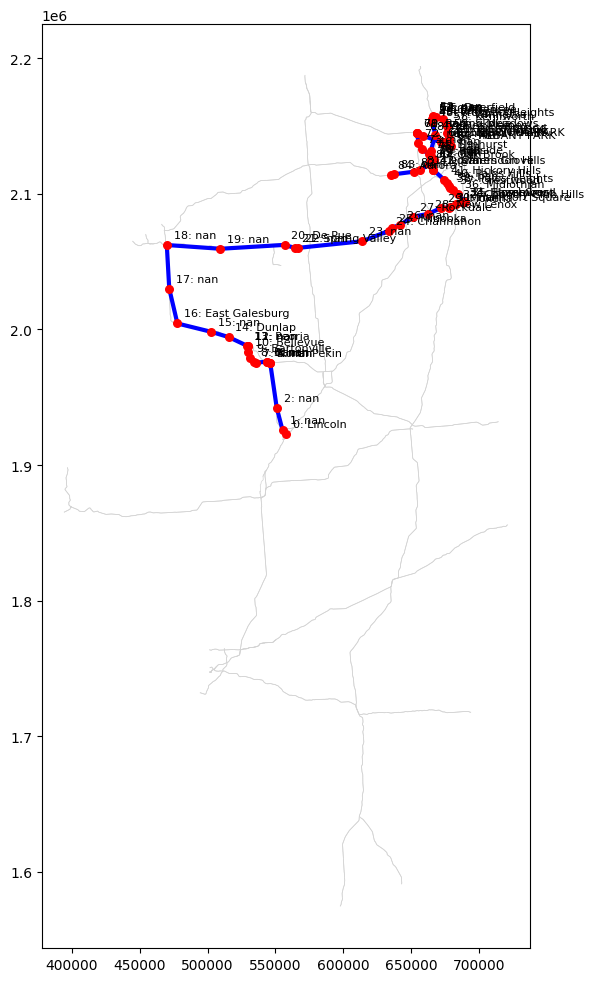

In [354]:
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import geopandas as gpd

# Create route line
route_geom = LineString([
    (G.nodes[n]["x"], G.nodes[n]["y"])
    for n in path
])

route_gdf = gpd.GeoDataFrame(
    geometry=[route_geom],
    crs=TARGET_CRS
)

# Create route nodes
route_points = gpd.GeoDataFrame(
    {
        "order": range(len(path)),
        "node": path,
        "PLACE_NAME": [
            G.nodes[n].get("PLACE_NAME")
            for n in path
        ]
    },
    geometry=[
        Point(
            G.nodes[n]["x"],
            G.nodes[n]["y"]
        )
        for n in path
    ],
    crs=TARGET_CRS
)

# Plot
fig, ax = plt.subplots(figsize=(12,12))

# optional: show road network
edges_gdf.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.5
)

# route
route_gdf.plot(
    ax=ax,
    color="blue",
    linewidth=3,
    zorder=2
)

# route points
route_points.plot(
    ax=ax,
    color="red",
    markersize=30,
    zorder=3
)

# labels
for _, row in route_points.iterrows():
    label = str(row["order"])

    if row["PLACE_NAME"]:
        label += f": {row['PLACE_NAME']}"

    ax.annotate(
        label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# ZoomToTheExtentOf(ax, ILCollarCountiesArea)

plt.show()

In [320]:
start_component = None
end_component = None

for i, component in enumerate(nx.connected_components(G)):
    if start_node in component:
        start_component = i
    if end_node in component:
        end_component = i

print(start_component, end_component)

4 9


In [336]:
import networkx as nx

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

print("Number of networks:", len(components))

for i, comp in enumerate(components[:10]):
    print(i, len(comp), "nodes")

Number of networks: 1
0 716 nodes


In [337]:
from shapely.geometry import LineString
import geopandas as gpd

component_edges = []

for i, component in enumerate(components):
    subgraph = G.subgraph(component)

    for u, v, data in subgraph.edges(data=True):

        # use existing geometry if available
        if "geometry" in data:
            geom = data["geometry"]

        # otherwise create line from nodes
        else:
            geom = LineString([
                (
                    G.nodes[u]["x"],
                    G.nodes[u]["y"]
                ),
                (
                    G.nodes[v]["x"],
                    G.nodes[v]["y"]
                )
            ])

        component_edges.append({
            "component": i,
            "nodes": len(component),
            "repaired": data.get("repaired", False),
            "geometry": geom
        })

component_edges_gdf = gpd.GeoDataFrame(
    component_edges,
    crs=atomic_roads.crs
)

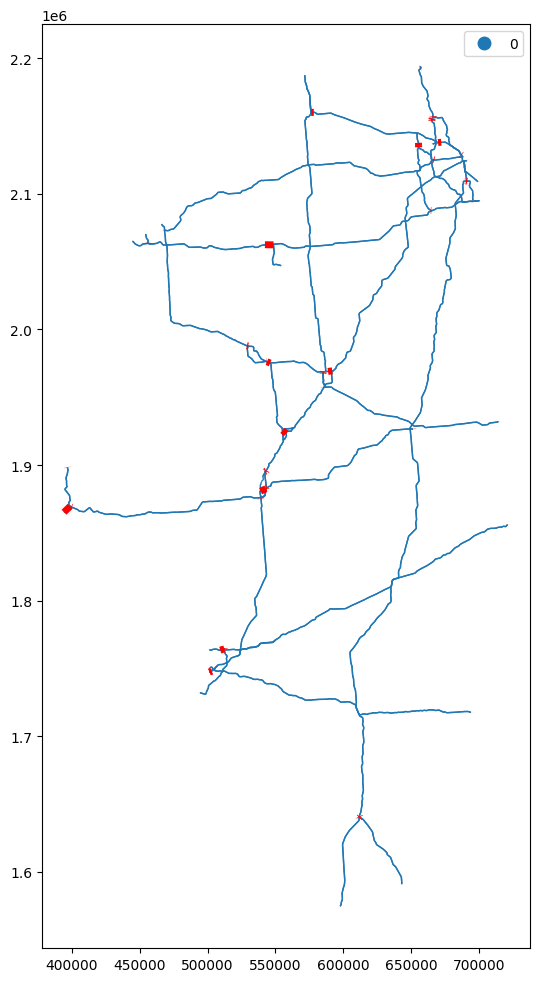

In [338]:
fig, ax = plt.subplots(figsize=(12,12))

component_edges_gdf.plot(
    ax=ax,
    column="component",
    categorical=True,
    linewidth=1,
    legend=True
)

component_edges_gdf[
    component_edges_gdf["repaired"]
].plot(
    ax=ax,
    color="red",
    linewidth=5
)

# ZoomToTheExtentOf(ax, ILMidStateArea)

plt.show()

In [324]:
from scipy.spatial import cKDTree
import numpy as np

def connect_closest_components(G, max_distance=50):
    """
    Connect disconnected components by closest node pairs.
    max_distance is in CRS units (meters for EPSG:5070).
    """

    components = list(nx.connected_components(G))

    while len(components) > 1:

        best_distance = float("inf")
        best_pair = None

        # compare every component pair
        for i in range(len(components)):
            for j in range(i + 1, len(components)):

                comp1 = list(components[i])
                comp2 = list(components[j])

                coords1 = np.array([
                    [G.nodes[n]["x"], G.nodes[n]["y"]]
                    for n in comp1
                ])

                coords2 = np.array([
                    [G.nodes[n]["x"], G.nodes[n]["y"]]
                    for n in comp2
                ])

                tree = cKDTree(coords2)

                distances, indices = tree.query(coords1)

                idx = distances.argmin()

                if distances[idx] < best_distance:
                    best_distance = distances[idx]
                    best_pair = (
                        comp1[idx],
                        comp2[indices[idx]]
                    )

        # stop if no close connection exists
        if best_distance > max_distance:
            print(
                "Closest components are",
                best_distance,
                "meters apart. Stopping."
            )
            break

        u, v = best_pair

        G.add_edge(
            u,
            v,
            length=best_distance,
            repaired=True
        )

        print(
            "Connected:",
            u,
            v,
            round(best_distance,2),
            "meters"
        )

        components = list(nx.connected_components(G))

    return G

In [334]:
tolerance = 4 * 1609.344

G_repaired = connect_closest_components(
    G,
    max_distance=tolerance
)

Connected: (558023.5111971941, 1923197.6358414716) (555318.9871880491, 1925626.230326503) 3634.9 meters
Connected: (539074.5447041551, 1880804.1443788104) (543025.4664757332, 1882616.8528208106) 4346.92 meters
Connected: (542282.2747167769, 2062502.8306073972) (548611.1977081645, 2062399.2306736987) 6329.77 meters
Connected: (394181.2629146205, 1865278.4881535145) (398730.5381376065, 1869716.4802277945) 6355.44 meters


In [335]:
print(nx.number_connected_components(G))

1


In [330]:
print(nx.number_connected_components(G_repaired))

5


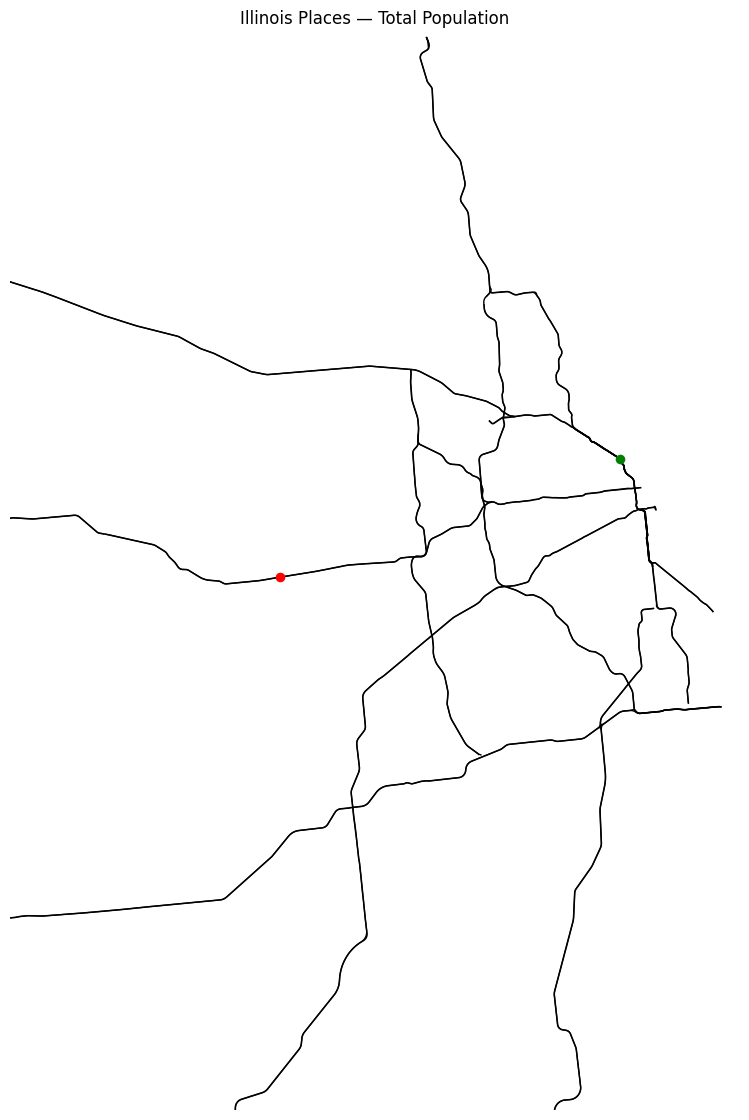

In [262]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

start_gdf = gpd.GeoDataFrame(
    [start_row],
    geometry="road_point",
    crs=TARGET_CRS
)
end_gdf = gpd.GeoDataFrame(
    [end_row],
    geometry="road_point",
    crs=TARGET_CRS
)



fig, ax = plt.subplots(figsize=(14, 14))

# ILRoads2025[(
#     ILRoads2025['RTTYP'] == 'S'
# )].plot(
#     ax=ax,
#     linewidth=1,
#     edgecolor='#000'
# )

# ILRoads2025[(
#     ILRoads2025['RTTYP'] == 'U'
# )].plot(
#     ax=ax,
#     linewidth=2,
#     edgecolor='#000'
# )

ILRoads2025[(
    ILRoads2025['RTTYP'] == 'I'
)].plot(
    ax=ax,
    linewidth=1,
    edgecolor='#000000',
    zorder=1
)


# place_road_points.plot(
#      ax=ax,
#      color="#000",
#      markersize=3
# )

start_gdf.plot(
    ax=ax,
    color="green",
    markersize=35,
    zorder=2
)

end_gdf.plot(
    ax=ax,
    color="red",
    markersize=35,
    zorder=2
)

    

ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")

ZoomToTheExtentOf(ax, ILCollarCountiesArea)


plt.show()